<a href="https://colab.research.google.com/github/Shivani767/llm-inferlite/blob/main/notebooks/inferlite_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InferLite on free Google Colab GPUs (T4)

Measured timings only. Missing methods are labeled **unsupported**, never scored.

**Published:** T4 lite (FP16 35.0 tok/s, INT4 15.3 tok/s) and llama.cpp GGUF Q4_K_M (172.5 tok/s).
**Next:** **T4 search vs baselines**. Do this on a **clean runtime** — not in the same session as lite or GGUF.

**T4 search (do this next)**

1. Runtime → **Restart session** (or Disconnect and delete if RAM already crashed).
2. T4 GPU. Run cells 1–3 only (clone + slim pip + capabilities).
3. **Skip** the lite suite and **skip** GGUF.
4. Run **T4 search vs baselines**. Four unique TinyLlama loads (fp16/INT4 × context 32/64). Paste the printed `comparison` JSON.

Never `pip install -r requirements.txt` (fills disk). Do not mix Mac GPT-2 search numbers with T4.


In [1]:
import os, sys, pathlib, subprocess

def is_repo(path):
    return (pathlib.Path(path) / "backend" / "research").is_dir()

REPO_ROOT = None
for cand in [
    pathlib.Path("/content/llm-inferlite"),
    pathlib.Path("/content/llm-inferlite-main"),
    pathlib.Path.cwd(),
    pathlib.Path.cwd().parent,
    pathlib.Path("/content"),
]:
    if is_repo(cand):
        REPO_ROOT = cand
        break
    for name in ("llm-inferlite", "llm-inferlite-main"):
        nested = cand / name
        if is_repo(nested):
            REPO_ROOT = nested
            break
    if REPO_ROOT is not None:
        break

if REPO_ROOT is None:
    dest = pathlib.Path("/content/llm-inferlite")
    print("Repo not found. Cloning https://github.com/Shivani767/llm-inferlite ...")
    subprocess.check_call([
        "git", "clone", "--depth", "1",
        "https://github.com/Shivani767/llm-inferlite.git",
        str(dest),
    ])
    REPO_ROOT = dest
elif (REPO_ROOT / ".git").is_dir():
    # Old clones still have the disk-filling pip cell files; fast-forward to origin/main.
    subprocess.call(["git", "-C", str(REPO_ROOT), "fetch", "--depth", "1", "origin", "main"])
    subprocess.call(["git", "-C", str(REPO_ROOT), "reset", "--hard", "origin/main"])

BACKEND = REPO_ROOT / "backend"
assert (BACKEND / "research").exists(), (
    f"Could not find InferLite backend under {REPO_ROOT}. "
    "Run: !git clone --depth 1 https://github.com/Shivani767/llm-inferlite.git /content/llm-inferlite"
)
os.chdir(BACKEND)
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))
print("REPO_ROOT", REPO_ROOT)
print("BACKEND ", BACKEND)

Repo not found. Cloning https://github.com/Shivani767/llm-inferlite ...
REPO_ROOT /content/llm-inferlite
BACKEND  /content/llm-inferlite/backend


In [8]:
from google.colab import files
from pathlib import Path
import importlib
import sys

dst = Path("/content/llm-inferlite/backend/research")
assert dst.is_dir(), "Clone missing. Re-run the first code cell."
sys.path.insert(0, str(dst.parent))

print("Select optimizer.py, metrics.py, runner.py, viz.py")
uploaded = files.upload()
needed = {"optimizer.py", "metrics.py", "runner.py", "viz.py"}
got = set(uploaded)
missing = needed - got
if missing:
    raise SystemExit(f"Still need: {sorted(missing)}")

for name, data in uploaded.items():
    path = dst / Path(name).name
    path.write_bytes(data)
    print("wrote", path, "bytes", len(data))

import research.metrics as m
import research.optimizer as o
import research.viz as v
import research.runner as r
importlib.reload(m)
importlib.reload(o)
importlib.reload(v)
importlib.reload(r)

from research.optimizer import run_budget_sweep
print("run_budget_sweep OK")

Select optimizer.py, metrics.py, runner.py, viz.py


Saving runner.py to runner (2).py
Saving optimizer.py to optimizer (2).py
Saving viz.py to viz (1).py
Saving metrics.py to metrics (1).py


SystemExit: Still need: ['metrics.py', 'optimizer.py', 'runner.py', 'viz.py']

In [9]:
from pathlib import Path
import importlib, re, sys

dst = Path("/content/llm-inferlite/backend/research")
sys.path.insert(0, str(dst.parent))

needed = ("optimizer.py", "metrics.py", "runner.py", "viz.py")
search_dirs = [Path("/content"), Path("/content/llm-inferlite/backend/research"), Path.cwd()]

def canon(name: str):
    n = Path(name).name.lower()
    n = re.sub(r"\s*\(\d+\)", "", n)  # optimizer (2).py -> optimizer.py
    return n

found = {}
for folder in search_dirs:
    if not folder.is_dir():
        continue
    for p in folder.glob("*.py"):
        key = canon(p.name)
        if key in needed:
            found[key] = p

missing = [n for n in needed if n not in found]
if missing:
    raise SystemExit(f"Still missing {missing}. Looked in {[str(d) for d in search_dirs]}")

for name in needed:
    src = found[name]
    target = dst / name
    target.write_bytes(src.read_bytes())
    print("wrote", target, "from", src, "bytes", target.stat().st_size)

import research.metrics as m
import research.optimizer as o
import research.viz as v
import research.runner as r
importlib.reload(m)
importlib.reload(o)
importlib.reload(v)
importlib.reload(r)

from research.optimizer import run_budget_sweep
print("run_budget_sweep OK")

wrote /content/llm-inferlite/backend/research/optimizer.py from /content/llm-inferlite/backend/optimizer.py bytes 25274
wrote /content/llm-inferlite/backend/research/metrics.py from /content/llm-inferlite/backend/metrics.py bytes 3156
wrote /content/llm-inferlite/backend/research/runner.py from /content/llm-inferlite/backend/runner (2).py bytes 11574
wrote /content/llm-inferlite/backend/research/viz.py from /content/llm-inferlite/backend/viz (1).py bytes 12812
run_budget_sweep OK


In [10]:
import shutil
from pathlib import Path

# Free leftover clones / pip cache from a crashed session. Do not reinstall torch.
for extra in (Path("/content/llm-inferlite-main"),):
    if extra.exists() and extra.resolve() != Path(REPO_ROOT).resolve():
        shutil.rmtree(extra, ignore_errors=True)

!pip cache purge -q || true
!df -h / | tail -1
!free -h | head -2

# Slim install only. NEVER: pip install -r requirements.txt on Colab.
!pip install -q -r requirements-colab.txt
print("install done")

overlay         113G   48G   66G  42% /
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.4Gi       5.9Gi       2.0Mi       5.3Gi        10Gi
install done


In [11]:
from research.capabilities import probe
from research.env import collect_environment
import json

env = collect_environment(seed=42)
caps = probe()
print("device:", caps["device"], "cuda:", caps["cuda"], "colab:", env.get("colab"))
print("gpu:", (env.get("torch") or {}).get("gpu"))
print("\nCapability matrix:")
for name, item in caps["experiments"].items():
    print(f"  [{'YES' if item['supported'] else 'NO ':3}] {name}: {item['reason']}")

device: cuda cuda: True colab: True
gpu: {'index': 0, 'name': 'Tesla T4', 'total_memory_mb': 14912.69, 'multi_processor_count': 40, 'major': 7, 'minor': 5}

Capability matrix:
  [YES] transformers_fp32: ready
  [YES] transformers_fp16: fp16 is measured on CUDA or MPS; CPU stays fp32
  [YES] transformers_bf16: bf16 measured on CUDA when the GPU supports it
  [YES] dynamic_int8: PyTorch dynamic int8 on Linear layers (CPU path is the supported one)
  [YES] int8_bnb: ready
  [YES] int4_bnb: ready
  [YES] gptq: ready to attempt GPTQ load
  [NO ] awq: autoawq not available: No module named 'autoawq'
  [NO ] gguf: llama_cpp not available: No module named 'llama_cpp'
  [NO ] vllm: vllm not available: No module named 'vllm'
  [NO ] tensorrt_llm: TensorRT-LLM is not installed or supported on MacBook / free Colab
  [NO ] smoothquant: SmoothQuant is not wired: needs a dedicated calibration toolkit not bundled here
  [NO ] squeezellm: SqueezeLLM is not bundled; no silent fallback numbers are produc

## T4 lite suite

**Skip these two cells after a RAM crash** if you already have the published FP16 / INT4 table. Re-running fp16 + INT8 + INT4 in the same session as search is what fills RAM.

TinyLlama 1.1B. Times **fp16, INT8, INT4** when bitsandbytes works. AWQ/GPTQ/GGUF stay **unsupported** unless those libraries and files are present.


In [ ]:
from research.runner import load_config, run_config

cfg_path = REPO_ROOT / "configs" / "colab_t4_lite.yaml"
cfg = load_config(cfg_path)
cfg["results_dir"] = str(BACKEND / "results" / "colab_t4_lite")

summary = run_config(cfg, results_dir=cfg["results_dir"], make_plots=True)
print("measured", summary["n_measured"], "unsupported", summary["n_unsupported"], "error", summary["n_error"])
print("bundle", summary["bundle"])
print("csv", summary["csv"])
print("plots", summary["plots"])
print("pareto", json.dumps(summary["pareto"], indent=2, default=str)[:2000])

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


[transformers] torch_dtype is deprecated; bitsandbytes logged repeated MatMul8bitLt bfloat16→float16 casts (truncated).


measured 4 unsupported 4 error 0
bundle /content/llm-inferlite/backend/results/colab_t4_lite/colab_t4_lite.json
csv /content/llm-inferlite/backend/results/colab_t4_lite/experiments.csv
plots ['/content/llm-inferlite/backend/results/colab_t4_lite/figures/quantization_comparison.png', '/content/llm-inferlite/backend/results/colab_t4_lite/figures/pareto_throughput_memory.png', '/content/llm-inferlite/backend/results/colab_t4_lite/figures/unsupported_experiments.png']
pareto [
  {
    "experiment_id": "2026-08-25T171238Z_fp16_2840abf2",
    "method": "fp16",
    "backend": "transformers",
    "model_id": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "device": "cuda",
    "objectives": {
      "p95_latency_ms": 467.91840940009024,
      "memory_mb": 2107.525,
      "tokens_per_sec": 34.97482779291871
    }
  },
  {
    "experiment_id": "2026-08-25T171320Z_int4_bnb_eaa6c99f",
    "method": "int4_bnb",
    "backend": "transformers",
    "model_id": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "devic

pareto_throughput_memory.png


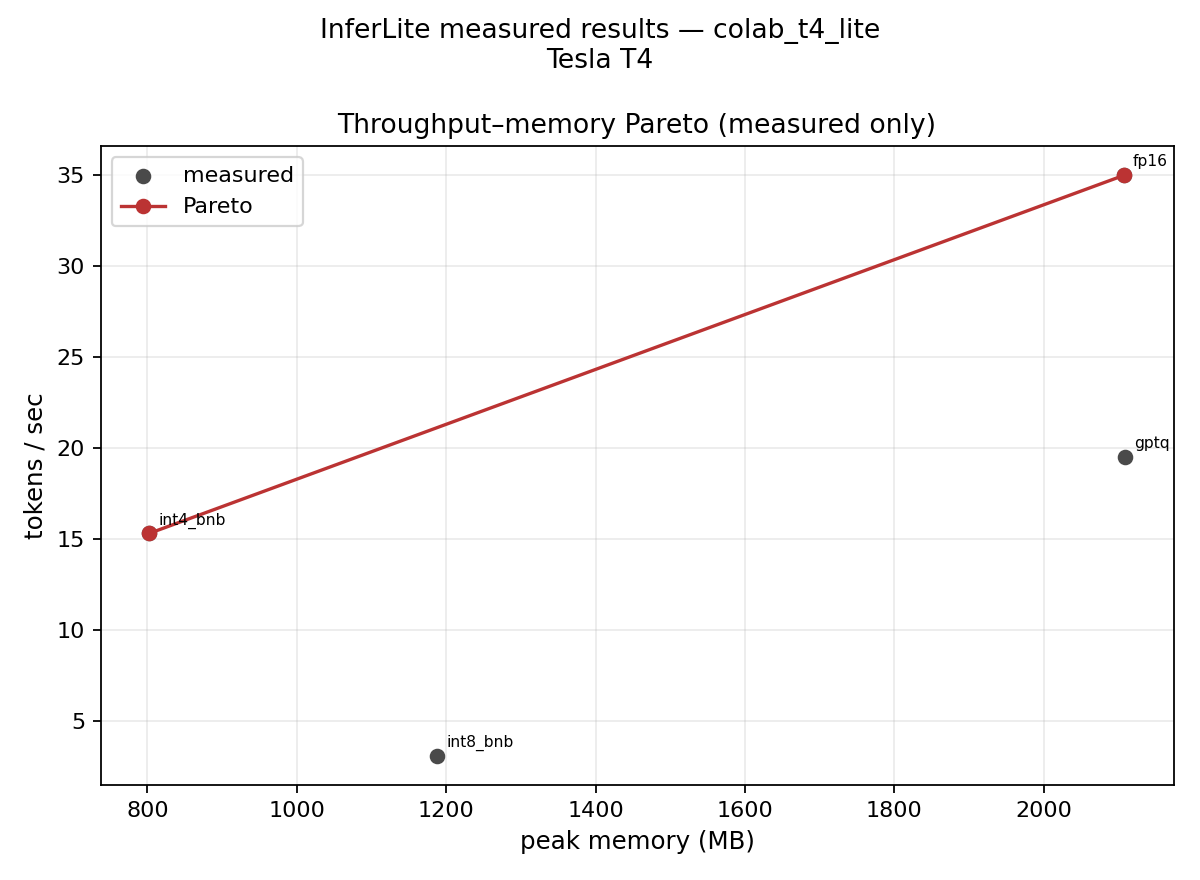

quantization_comparison.png


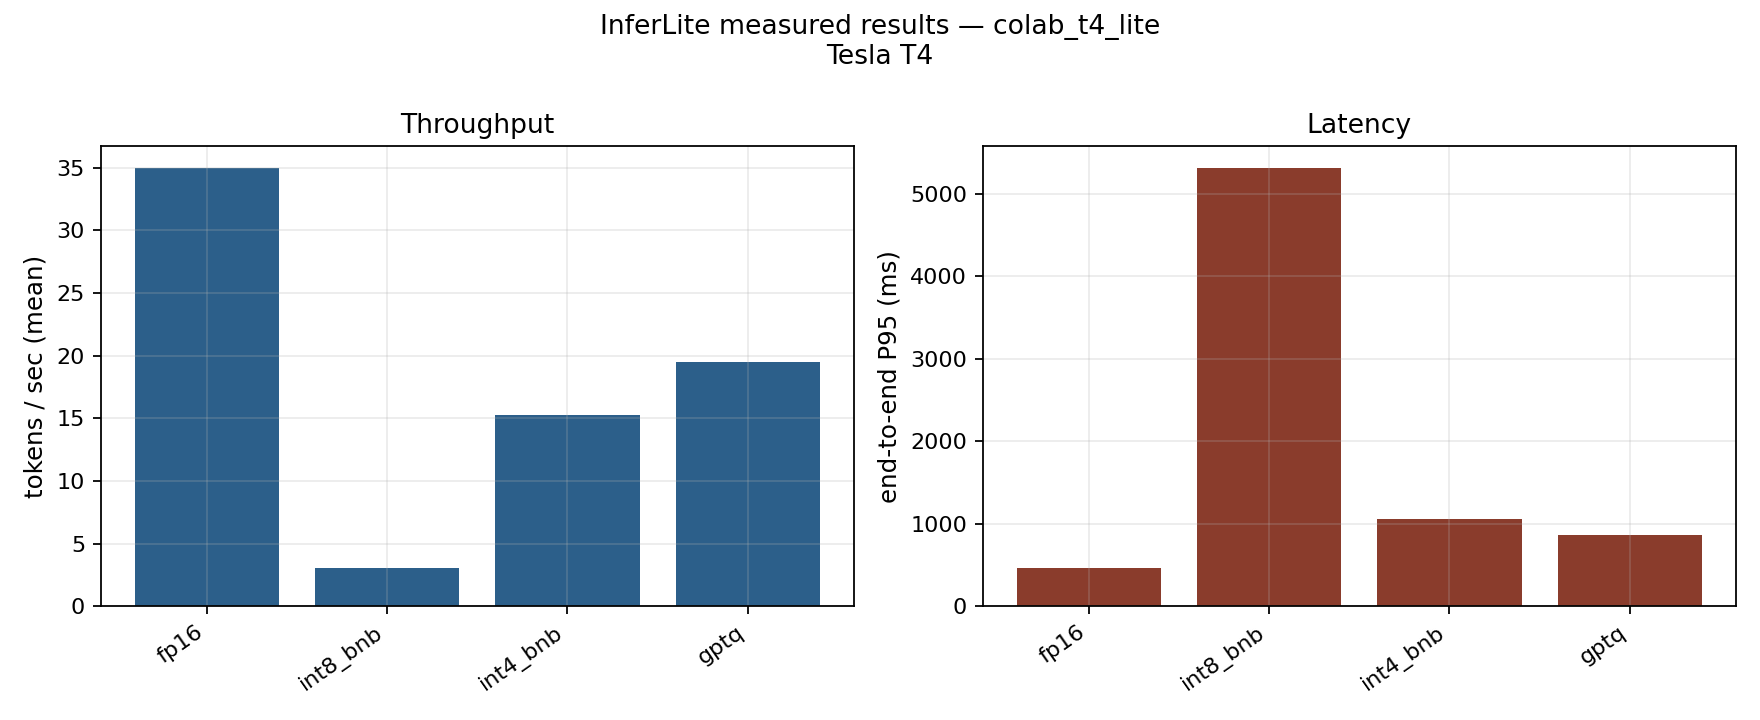

unsupported_experiments.png


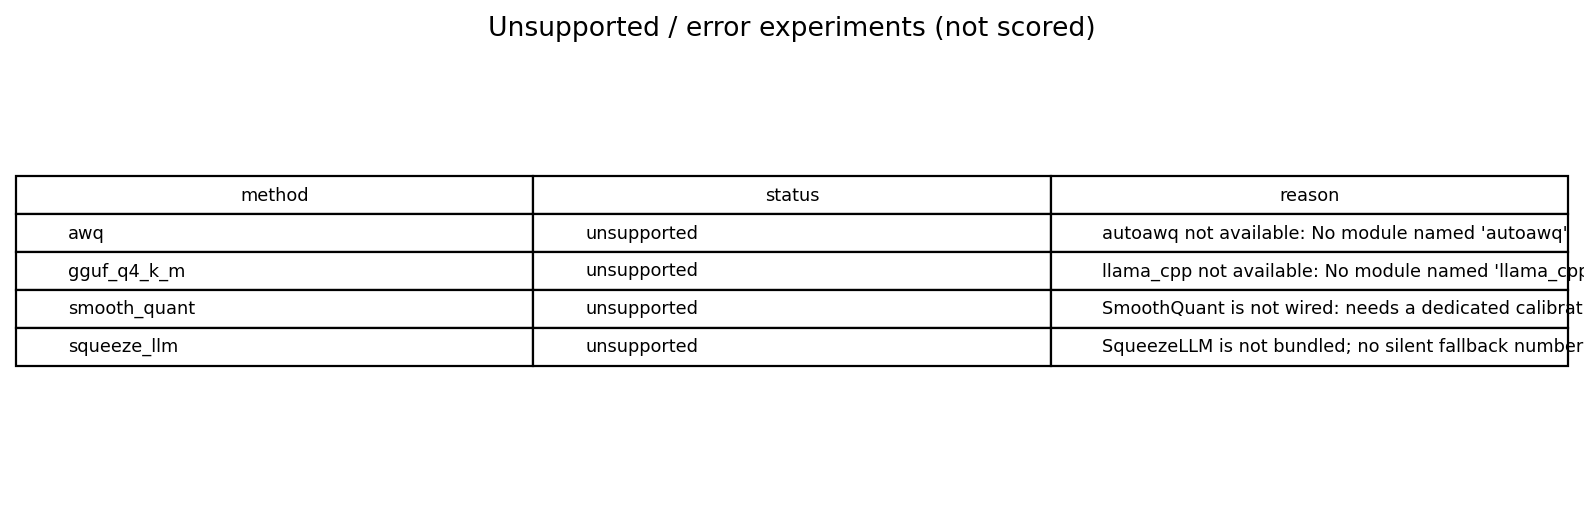

In [ ]:
from IPython.display import Image, display
from pathlib import Path

fig_dir = Path(cfg["results_dir"]) / "figures"
if fig_dir.exists():
    for p in sorted(fig_dir.glob("*.png")):
        print(p.name)
        display(Image(filename=str(p)))
else:
    print("No figures yet. Check n_measured in the previous cell.")

## T4 search vs baselines (RAM-safe)

**Run this on a clean runtime.** Skip if you just ran lite or GGUF in this session — **Restart session**, re-run cells 1–3, skip those suites, then this cell.

Four unique loads: TinyLlama **fp16** / **INT4** × context **32** / **64**, 8 new tokens. Grid is 4 jobs. Random and InferLite get budget **2** and **reuse** the cache (they do not reload TinyLlama 12 times).

Paste the printed `comparison` and grid rows so the T4 search table can be published. Do not mix with Mac GPT-2 HV.


In [ ]:
import gc, json
from pathlib import Path

try:
    import torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
except Exception:
    pass

import psutil
avail_gb = psutil.virtual_memory().available / (1024 ** 3)
print(f"available RAM {avail_gb:.1f} GiB")
!free -h | head -2
!nvidia-smi --query-gpu=memory.used,memory.total --format=csv,noheader || true
if avail_gb < 6:
    raise SystemExit(
        "RAM too low for TinyLlama search. Runtime → Restart session, "
        "re-run cells 1–3, skip lite and GGUF, then run this cell."
    )

from research.runner import load_config, run_config

cfg_path = REPO_ROOT / "configs" / "optimizer_colab_t4.yaml"
assert cfg_path.exists(), (
    f"Missing {cfg_path}. Re-run cell 1 so the clone is on origin/main."
)
cfg = load_config(cfg_path)
cfg["results_dir"] = str(BACKEND / "results" / "optimizer_colab_t4")
search = run_config(cfg, results_dir=cfg["results_dir"], make_plots=True)
print("measured", search["n_measured"], "unsupported", search["n_unsupported"], "error", search["n_error"])
print("grid rows:")
for rec in search.get("records") or []:
    metrics = rec.get("metrics") or {}
    tps = (metrics.get("tokens_per_sec") or {}).get("mean")
    p95 = (metrics.get("e2e_latency_ms") or {}).get("p95")
    mem = metrics.get("peak_gpu_allocated_mb") or metrics.get("peak_rss_mb")
    key = (rec.get("config") or {}).get("candidate_key")
    print(rec.get("status"), rec.get("method"), key, "tok/s", tps, "P95", p95, "mem", mem)
study_path = Path(cfg["results_dir"]) / "search_study.json"
if study_path.exists():
    study = json.loads(study_path.read_text())
    print(json.dumps(study.get("comparison"), indent=2))
print("csv", search["csv"])


available RAM 10.9 GiB
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.5Gi       5.8Gi       2.0Mi       5.4Gi        10Gi
3 MiB, 15360 MiB
[search grid] fp16|c32|n8|b1


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

[search grid] int4_bnb|c32|n8|b1


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[search grid] int4_bnb|c64|n8|b1


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[search random] fp16|c32|n8|b1
[search random] int4_bnb|c64|n8|b1
[search heuristic] fp16|c64|n8|b1
[search inferlite] fp16|c64|n8|b1
[search inferlite] int4_bnb|c64|n8|b1
measured 4 unsupported 0 error 0
grid rows:
Status.MEASURED fp16 fp16|c32|n8|b1 tok/s 6.124797905211907 P95 1306.1655459998747 mem 2110.056
Status.MEASURED fp16 fp16|c64|n8|b1 tok/s 31.82391661453072 P95 251.3832629999797 mem 2113.514
Status.MEASURED int4_bnb int4_bnb|c32|n8|b1 tok/s 18.716541214256274 P95 427.42940099992666 mem 804.256
Status.MEASURED int4_bnb int4_bnb|c64|n8|b1 tok/s 15.370143212461114 P95 520.4896200000348 mem 826.646
[
  {
    "strategy": "grid",
    "n_evaluated": 4,
    "n_measured": 4,
    "hypervolume": 31262.634563673604,
    "hv_vs_grid": 1.0,
    "simulation": false
  },
  {
    "strategy": "random",
    "n_evaluated": 2,
    "n_measured": 2,
    "hypervolume": 1285.936883813275,
    "hv_vs_grid": 0.04113334982034756,
    "simulation": false
  },
  {
    "strategy": "heuristic",
    "n_eva

{
  "n_measured": 4,
  "variants": {
    "full": {
      "n": 4,
      "drop": [],
      "targets": {
        "p95_latency_ms": {
          "n": 4,
          "mae": 1118.4568044978378,
          "rmse": 1118.6387736869121,
          "r2": -6.659095535766684
        },
        "tokens_per_sec": {
          "n": 4,
          "mae": 28.301927964069215,
          "rmse": 28.305735608295,
          "r2": -8.438537105852872
        },
        "memory_mb": {
          "n": 4,
          "mae": 18.44732547005026,
          "rmse": 22.32849972380415,
          "r2": 0.9988134694183929
        }
      }
    },
    "no_hardware": {
      "n": 4,
      "drop": [
        "hardware"
      ],
      "targets": {
        "p95_latency_ms": {
          "n": 4,
          "mae": 1118.4568044978369,
          "rmse": 1118.6387736869115,
          "r2": -6.659095535766674
        },
        "tokens_per_sec": {
          "n": 4,
          "mae": 28.301927964069066,
          "rmse": 28.30573560829485,
        

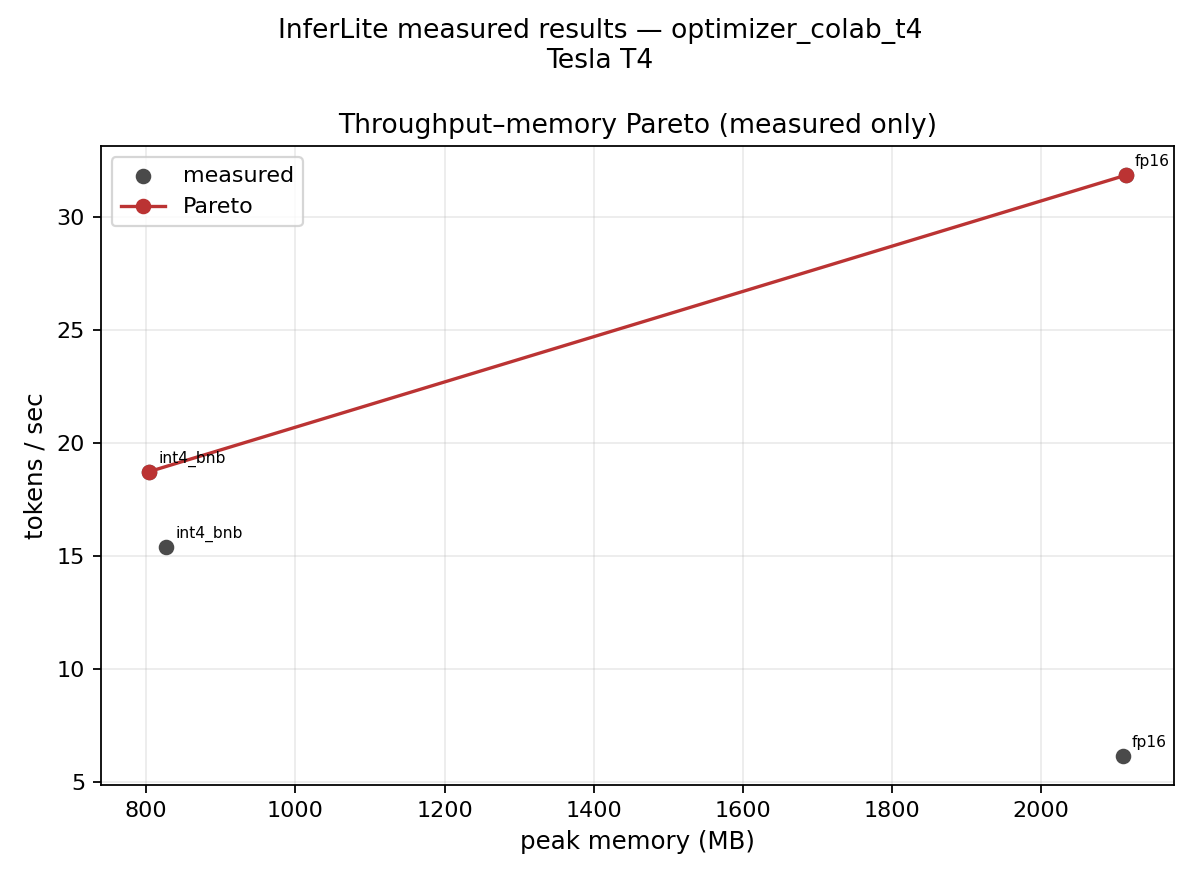

predictor_ablation.png


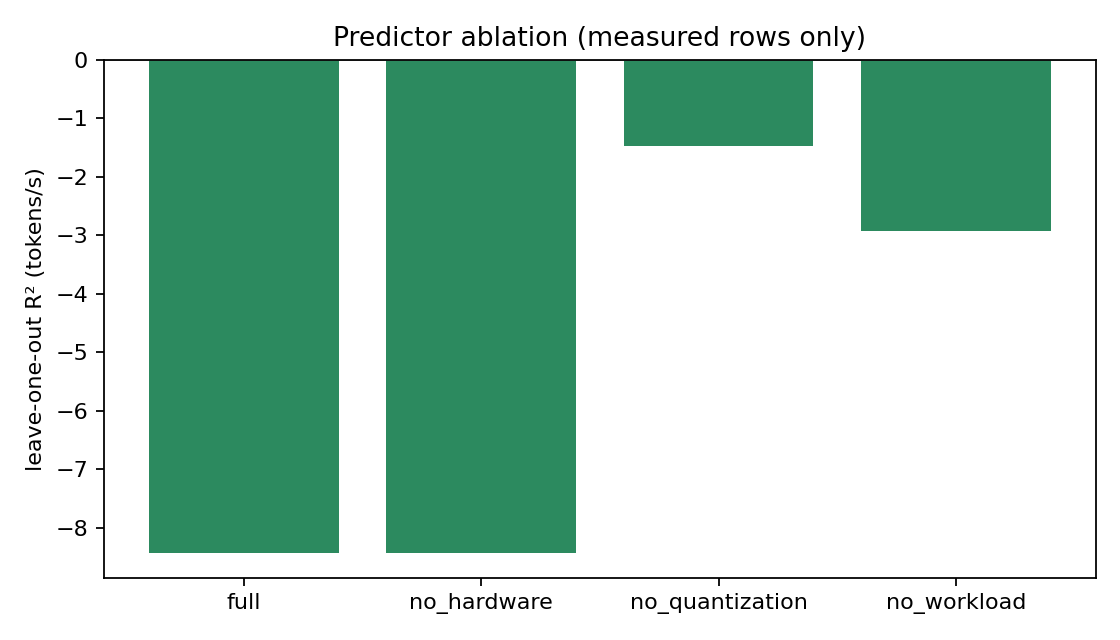

search_vs_baselines.png


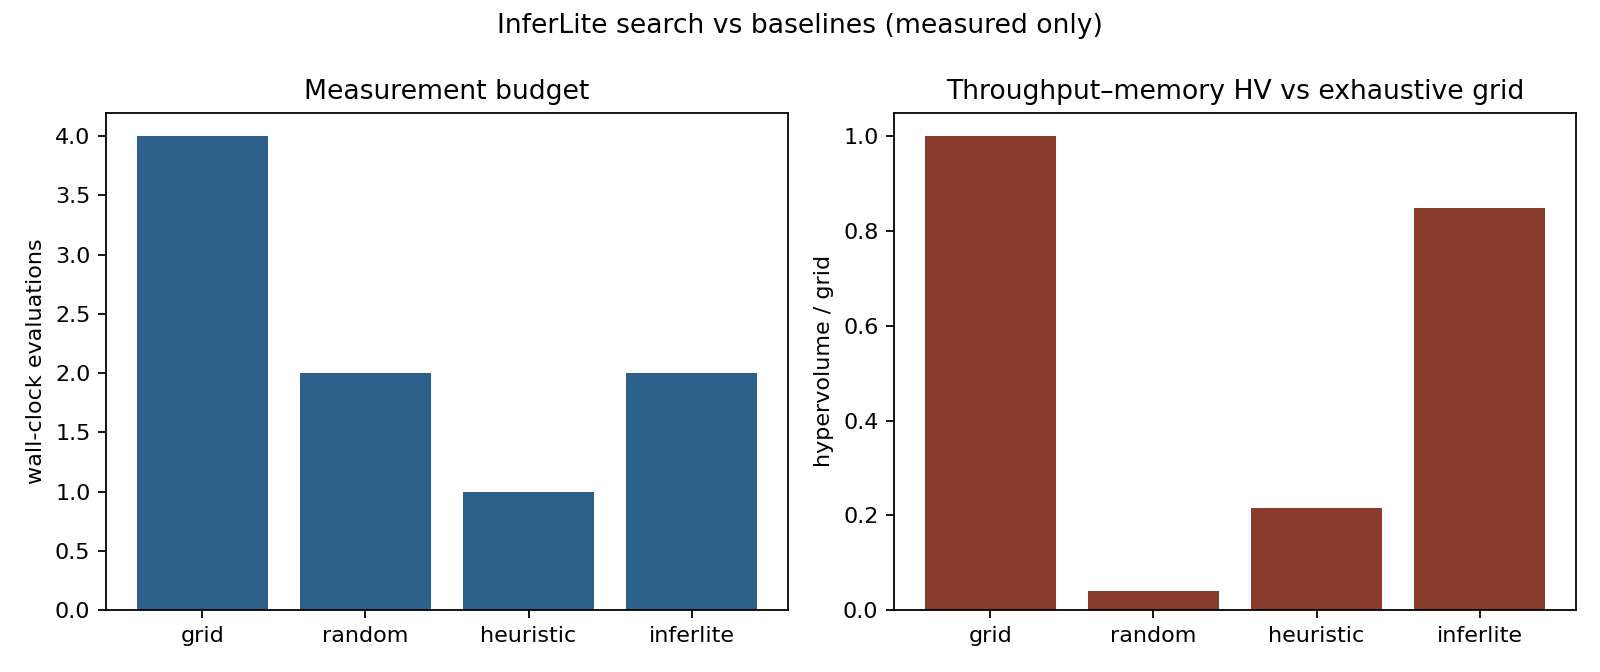

In [ ]:
from research.predictor import ablation_study
from research.storage import ResultStore
from IPython.display import Image, display
from pathlib import Path
import json

bundle = Path(cfg["results_dir"]) / "optimizer_colab_t4.json"
recs = ResultStore(cfg["results_dir"]).load_json_file(bundle)
measured = [r for r in recs if r.status.value == "measured"]
report = ablation_study(measured)
print(json.dumps(report, indent=2, default=str))
fig_dir = Path(cfg["results_dir"]) / "figures"
if fig_dir.exists():
    for p in sorted(fig_dir.glob("*.png")):
        print(p.name)
        display(Image(filename=str(p)))


## llama.cpp / GGUF (TinyLlama Q4_K_M)

The previous skip (`No module named 'llama_cpp'`) was expected: the slim Colab install does not include llama.cpp.

This cell installs a **prebuilt wheel only** (no 30–40 min source compile). Then it times `tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf` (~670 MB) with the **same 16-token workload** as the T4 lite suite.

If GPU offload is compiled in, `n_gpu_layers=-1`. If only a CPU wheel imported, the row is still measured — label it CPU, do not mix with CUDA.

Skip lite + search before this if RAM is tight. `gc.collect()` runs first.


In [ ]:
import gc, json
from pathlib import Path

try:
    import torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
except Exception:
    pass
!df -h / | tail -1
!free -h | head -2

from research.llama_cpp_setup import ensure_llama_cpp
from research.capabilities import probe
from research.runner import load_config, run_config

setup = ensure_llama_cpp()
print(json.dumps(setup, indent=2, default=str)[:2000])
if not setup.get("ok"):
    print("GGUF remains unsupported. Do not invent tok/s. Reopen the notebook from GitHub if this helper is missing.")
else:
    print("gguf capability:", probe()["experiments"]["gguf"])
    cfg_path = REPO_ROOT / "configs" / "colab_t4_gguf.yaml"
    assert cfg_path.exists(), f"Missing {cfg_path}. Re-run cell 1 so the clone is on origin/main."
    cfg = load_config(cfg_path)
    cfg["results_dir"] = str(BACKEND / "results" / "colab_t4_gguf")
    gguf = run_config(cfg, results_dir=cfg["results_dir"], make_plots=True)
    print("measured", gguf["n_measured"], "unsupported", gguf["n_unsupported"], "error", gguf["n_error"])
    recs = gguf.get("records") or []
    for rec in recs:
        print(rec.get("status"), rec.get("method"), rec.get("backend"), rec.get("reason"))
        metrics = rec.get("metrics") or {}
        extra = (metrics.get("extra") or {}).get("backend_extras") or {}
        print("n_gpu_layers", extra.get("n_gpu_layers"), "gpu_offload_compiled", extra.get("gpu_offload_compiled"))
        tps = ((metrics.get("tokens_per_sec") or {}) or {}).get("mean")
        p95 = ((metrics.get("e2e_latency_ms") or {}) or {}).get("p95")
        mem = metrics.get("peak_gpu_allocated_mb") or metrics.get("peak_rss_mb")
        print("tok/s", tps, "P95 ms", p95, "mem MB", mem)
    print("csv", gguf["csv"])


overlay         113G   50G   64G  44% /
               total        used        free      shared  buff/cache   available
Mem:            12Gi       7.6Gi       158Mi        16Mi       4.9Gi       4.8Gi


## This T4 lite run (2026-08-25)

**4 measured, 4 unsupported, 0 error.** Exact Pareto stdout:

| Method | tok/s | P95 e2e (ms) | GPU mem (MB) |
|--------|------:|-------------:|-------------:|
| fp16 | 34.975 | 467.92 | 2107.5 |
| int4_bnb | 15.306 | 1056.69 | 802.7 |

INT8 was measured and dominated (~3 tok/s, ~5.4 s P95 on the figure). The `gptq` bar loaded dense TinyLlama — **not a GPTQ checkpoint**.

Mac GPT-2 search (separate device): random 0.32× grid HV, InferLite 0.30×, heuristic 0.22×; predictor P95 R² 0.86, tok/s 0.51, memory 0.999. Do not copy those HV numbers into a T4 table.


## Honesty checklist

- Do not copy old README tables that listed Llama-3-8B TensorRT-LLM TPS. Those were simulations.
- Cite only `status=measured` rows, with this notebook's environment dump.
- If a method is `unsupported`, report the reason, not a guessed speedup.

## T4 scale study (30 configs × 5 seeds × budgets 2/4/8/16)

Clean runtime only. Skip lite, n=4 search, and GGUF.

30 TinyLlama jobs (`fp16` / `INT4` × context 32/48/64/96/128 × 8/12/16 new tokens). `warmup_runs=1`. Grid is timed once; random / InferLite / heuristic replay those measurements at seeds 42, 123, 456, 789, 1000 and budgets 2 / 4 / 8 / 16.

If this cell does not finish, those HV numbers do not exist. Do not copy Mac results here.


available RAM 10.8 GiB
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.5Gi       5.8Gi       2.0Mi       5.3Gi        10Gi
3 MiB, 15360 MiB
wrote /content/llm-inferlite/configs/optimizer_colab_t4_scale.yaml
[search grid] measuring 30 configurations once (wall-clock)
[search grid] fp16|c32|n8|b1


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[search grid] fp16|c32|n12|b1
[search grid] fp16|c32|n16|b1
[search grid] fp16|c48|n8|b1
[search grid] fp16|c48|n12|b1
[search grid] fp16|c48|n16|b1
[search grid] fp16|c64|n8|b1
[search grid] fp16|c64|n12|b1
[search grid] fp16|c64|n16|b1
[search grid] fp16|c96|n8|b1
[search grid] fp16|c96|n12|b1
[search grid] fp16|c96|n16|b1
[search grid] fp16|c128|n8|b1
[search grid] fp16|c128|n12|b1
[search grid] fp16|c128|n16|b1
[search grid] int4_bnb|c32|n8|b1


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[search grid] int4_bnb|c32|n12|b1
[search grid] int4_bnb|c32|n16|b1
[search grid] int4_bnb|c48|n8|b1
[search grid] int4_bnb|c48|n12|b1
[search grid] int4_bnb|c48|n16|b1
[search grid] int4_bnb|c64|n8|b1
[search grid] int4_bnb|c64|n12|b1
[search grid] int4_bnb|c64|n16|b1
[search grid] int4_bnb|c96|n8|b1
[search grid] int4_bnb|c96|n12|b1
[search grid] int4_bnb|c96|n16|b1
[search grid] int4_bnb|c128|n8|b1
[search grid] int4_bnb|c128|n12|b1
[search grid] int4_bnb|c128|n16|b1
measured 30 unsupported 0 error 0
grid rows:
Status.MEASURED fp16 fp16|c32|n8|b1 tok/s 33.44082104974514 P95 239.2285759999595 mem 2110.056
Status.MEASURED fp16 fp16|c32|n12|b1 tok/s 33.50000937303002 P95 358.2088549999298 mem 2110.056
Status.MEASURED fp16 fp16|c32|n16|b1 tok/s 31.73945009243551 P95 504.10451200013995 mem 2110.056
Status.MEASURED fp16 fp16|c48|n8|b1 tok/s 32.931648453597035 P95 242.9274080000141 mem 2111.785
Status.MEASURED fp16 fp16|c48|n12|b1 tok/s 34.47949030186532 P95 348.0329870001242 mem 2111.785


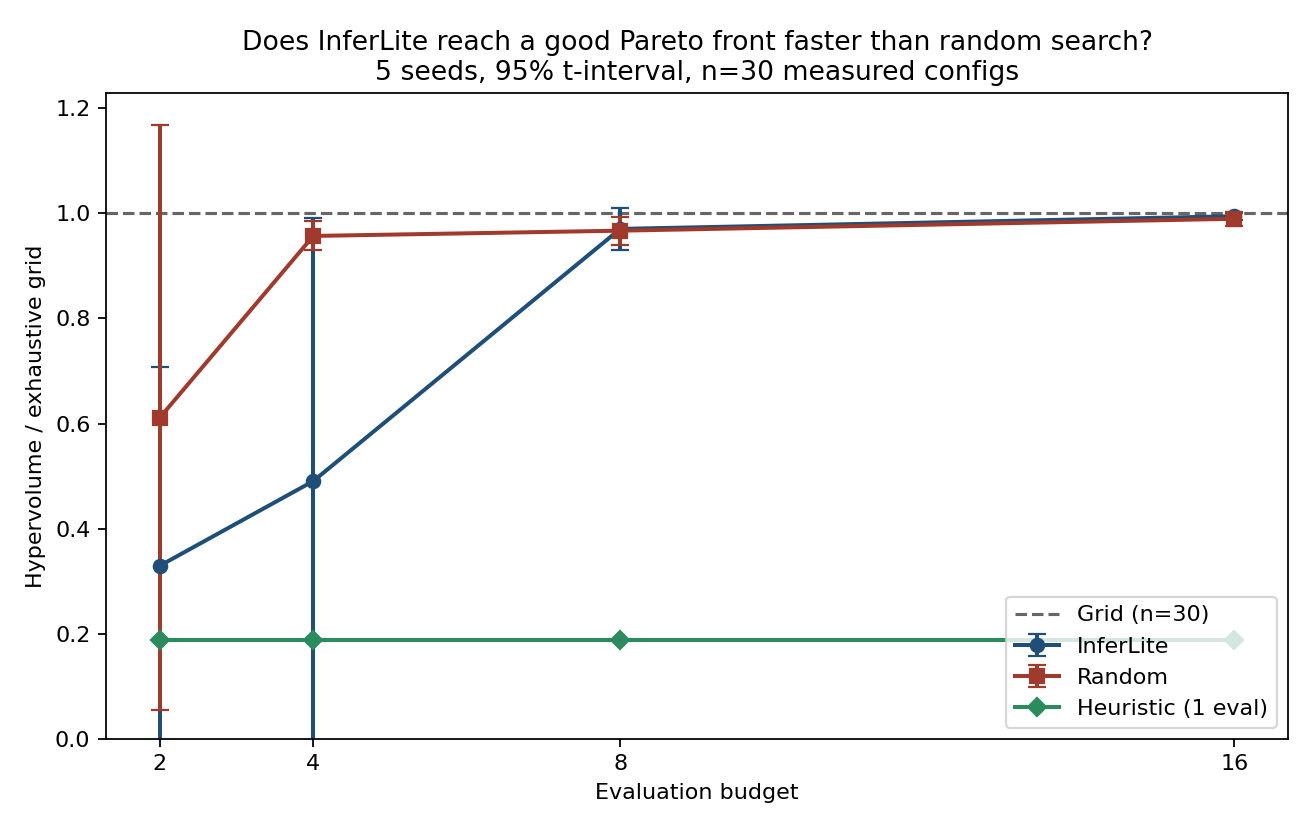

zip /content/optimizer_colab_t4_scale.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import gc, json, textwrap
from pathlib import Path

try:
    import torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
except Exception:
    pass

import psutil
avail_gb = psutil.virtual_memory().available / (1024 ** 3)
print(f"available RAM {avail_gb:.1f} GiB")
!free -h | head -2
!nvidia-smi --query-gpu=memory.used,memory.total --format=csv,noheader || true
if avail_gb < 6:
    raise SystemExit(
        "RAM too low. Runtime → Restart session, re-run clone + pip + capabilities, "
        "skip lite / n=4 search / GGUF, then this cell."
    )

from research.optimizer import run_budget_sweep  # needs the updated optimizer.py on the clone

cfg_path = REPO_ROOT / "configs" / "optimizer_colab_t4_scale.yaml"
cfg_path.parent.mkdir(parents=True, exist_ok=True)
cfg_path.write_text(textwrap.dedent("""
    name: optimizer_colab_t4_scale
    seed: 42
    seeds: [42, 123, 456, 789, 1000]
    budgets: [2, 4, 8, 16]
    model_id: TinyLlama/TinyLlama-1.1B-Chat-v1.0
    warmup_runs: 1
    measure_runs: 1
    keep_one_method: true
    results_dir: results/optimizer_colab_t4_scale
    search_space:
      methods: [fp16, int4_bnb]
      context_tokens: [32, 48, 64, 96, 128]
      max_new_tokens: [8, 12, 16]
      batch_sizes: [1]
      skip_unsupported: true
    strategies: [grid, random, heuristic, inferlite]
    experiments:
      - type: search
""").lstrip())
print("wrote", cfg_path)

from research.runner import load_config, run_config

cfg = load_config(cfg_path)
cfg["results_dir"] = str(BACKEND / "results" / "optimizer_colab_t4_scale")
search = run_config(cfg, results_dir=cfg["results_dir"], make_plots=True)
print("measured", search["n_measured"], "unsupported", search["n_unsupported"], "error", search["n_error"])
print("grid rows:")
for rec in search.get("records") or []:
    metrics = rec.get("metrics") or {}
    tps = (metrics.get("tokens_per_sec") or {}).get("mean")
    p95 = (metrics.get("e2e_latency_ms") or {}).get("p95")
    mem = metrics.get("peak_gpu_allocated_mb") or metrics.get("peak_rss_mb")
    key = (rec.get("config") or {}).get("candidate_key")
    print(rec.get("status"), rec.get("method"), key, "tok/s", tps, "P95", p95, "mem", mem)

sweep_path = Path(cfg["results_dir"]) / "budget_sweep.json"
csv_path = Path(cfg["results_dir"]) / "hv_vs_budget.csv"
if sweep_path.exists():
    sweep = json.loads(sweep_path.read_text())
    print("n_search_space", sweep.get("n_search_space"), "seeds", sweep.get("seeds"), "budgets", sweep.get("budgets"))
    print(json.dumps(sweep.get("inferlite_vs_random"), indent=2))
    print(json.dumps(sweep.get("comparison"), indent=2))
if csv_path.exists():
    print(csv_path.read_text())
print("csv", search["csv"])

from IPython.display import Image, display
fig = Path(cfg["results_dir"]) / "figures" / "hv_vs_budget.png"
if fig.exists():
    display(Image(filename=str(fig)))

import shutil
zip_base = Path("/content/optimizer_colab_t4_scale")
out_dir = Path(cfg["results_dir"])
if out_dir.exists():
    shutil.make_archive(str(zip_base), "zip", root_dir=out_dir)
    print("zip", zip_base.with_suffix(".zip"))
    try:
        from google.colab import files
        files.download(str(zip_base.with_suffix(".zip")))
    except Exception as exc:
        print("download skipped:", type(exc).__name__, exc)